#About Dataset
Context
Typically e-commerce datasets are proprietary and consequently hard to find among publicly available data. However, The UCI Machine Learning Repository has made this dataset containing actual transactions from 2010 and 2011. The dataset is maintained on their site, where it can be found by the title "Online Retail".

Link:
https://www.kaggle.com/datasets/carrie1/ecommerce-data/data

#Importing relevant Libaries and Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


__Importing the dataset and putting it in a dataframe__

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/WTF_Nov_Monthend_project/data.csv', encoding='latin1')

#Exploratory Data Analysis

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

There are 541909 row and 8 columns of data entries

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


We have about 2 float datatype, an int, and 5 objects(non-numeric) and also we have missing values in the `description` and `CustomerID` columns

In [ ]:
print("\n--- Missing values ---")
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0].head(50))


--- Missing values ---
CustomerID     135080
Description      1454
dtype: int64


In [ ]:
135080/541909*100

24.926694334288598

It seems like the missing values in `Description` are likely due to cancelled or promotional items, given that they have a `UnitPrice` of 0.0 and are also missing `CustomerID`, but we would be conducting more investigaion o be more certain.

Also dropping these rows means losing about 1,454 (0.3% entries) row entries, though relatively small in ratio to the percentage of the overall data, but as for the missing `CustomerID` values, we would be losing about 135,080 (25% entries), which is a lot of data to be removed. Hence it wouldn't be an optimal option for now till more investigation is carried out.

In [ ]:
df[df['CustomerID'].isnull()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,12/1/2010 14:32,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,12/1/2010 14:32,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,12/1/2010 14:32,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,12/1/2010 14:32,0.43,NaN,United Kingdom


In [ ]:
df[df['Description'].isnull()].tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
524473,580580,21804,NaN,10,12/5/2011 10:33,0.0,NaN,United Kingdom
524475,580588,21808,NaN,5,12/5/2011 10:35,0.0,NaN,United Kingdom
529667,580743,47591B,NaN,1,12/6/2011 9:30,0.0,NaN,United Kingdom
533711,581102,21803,NaN,20,12/7/2011 11:57,0.0,NaN,United Kingdom
533712,581103,22689,NaN,4,12/7/2011 11:58,0.0,NaN,United Kingdom
535322,581199,84581,NaN,-2,12/7/2011 18:26,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,12/7/2011 18:31,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,12/7/2011 18:35,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,12/8/2011 10:33,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,12/8/2011 14:06,0.0,NaN,United Kingdom


I also noticed that some values in the `UnitPrice` is equal to zero when `CustomerID` is empty, so we needed to know if they have any form of relation with the missingness. Hence further investigation was needed.

In [ ]:
mask = (df['CustomerID'].isna() & (df['UnitPrice'] == 0))
mask.value_counts()

,count
False,539434
True,2475


In [ ]:
df.loc[mask].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,12/1/2010 14:35,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,12/1/2010 14:35,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,12/1/2010 16:50,0.0,NaN,United Kingdom


In [ ]:
pd.crosstab(df['CustomerID'].isna(), df['UnitPrice'] == 0)

UnitPrice,False,True
CustomerID,,
False,406789,40
True,132605,2475


In [ ]:
406789+ 132605+ 40

539434

A cross-tabulation between CustomerID missingness and zero UnitPrice shows that most missing customer records are not associated with zero-priced transactions. Out of the full dataset, only 2,475 rows have both a missing CustomerID and a zero UnitPrice, indicating these are likely system-generated records such as cancellations, test transactions, or manual adjustments rather than normal sales. The majority of missing CustomerID values (132,605 rows) occur in legitimate transactions with positive prices, suggesting the missingness is structural (e.g., guest checkouts) rather than random.

The scenerios are clearly explained in the table below:

| Scenario                                | Meaning                                            | Count       |
| --------------------------------------- | -------------------------------------------------- | ----------- |
| `CustomerID NOT NULL` & `UnitPrice > 0` | Normal, valid transactions                         | **406,789** |
| `CustomerID NOT NULL` & `UnitPrice = 0` | Rare zero-price rows (mostly adjustments)          | **40**      |
| `CustomerID IS NULL` & `UnitPrice > 0`  | Guest/anonymous customers                          | **132,605** |
| `CustomerID IS NULL` & `UnitPrice = 0`  | Likely cancelled test rows, or system entries | **2,475**   |

__Hence, Only 2,475 rows (~0.46% of data) match my original “missing CustomerID + zero price” theory.__

We also had to investigate why `InvoiceNo` is of object dtype instead of numeric dtype as the name implies

In [ ]:
df['InvoiceNo'].unique()

array(['536365', '536366', '536367', ..., '581585', '581586', '581587'],
      dtype=object)

In [ ]:
df[~df['InvoiceNo'].astype(str).str.fullmatch(r'\d+')]['InvoiceNo'].unique()[:50]

array(['C536379', 'C536383', 'C536391', 'C536506', 'C536543', 'C536548',
       'C536606', 'C536622', 'C536625', 'C536642', 'C536734', 'C536737',
       'C536757', 'C536758', 'C536760', 'C536807', 'C536812', 'C536814',
       'C536815', 'C536816', 'C536817', 'C536818', 'C536820', 'C536822',
       'C536825', 'C536826', 'C536827', 'C536828', 'C536829', 'C536850',
       'C536853', 'C536854', 'C536855', 'C536978', 'C536979', 'C537024',
       'C537039', 'C537043', 'C537132', 'C537143', 'C537157', 'C537164',
       'C537203', 'C537232', 'C537234', 'C537251', 'C537314', 'C537320',
       'C537333', 'C537373'], dtype=object)

The output above shows unique `InvoiceNo` values that contain non-numeric characters. The `C- prefixing The Invoice number` might indicate special transaction types, such as cancellations, discounts, or adjustments, rather than standard sales. To make sure that this is also true, further investigation is required.

In [ ]:
df['is_cancellation'] = df['InvoiceNo'].astype(str).str.startswith('C')

In [ ]:
df[df['is_cancellation']].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancellation
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom,True
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,True
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,True
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,True
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,True
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12/1/2010 10:24,3.45,17548.0,United Kingdom,True
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,True
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12/1/2010 10:24,1.65,17548.0,United Kingdom,True
939,C536506,22960,JAM MAKING SET WITH JARS,-6,12/1/2010 12:38,4.25,17897.0,United Kingdom,True


In [ ]:
# Check if all cancellation invoices have negative quantities
(df[df['is_cancellation']]['Quantity'] < 0).value_counts()

,count
Quantity,
True,9288


The `C- prefixing The Invoice number` appears to be cancelled invoices instead because the Quantity columns for any entry with C prefixing invoice holds a negative value

In [ ]:
df['is_cancellation'].value_counts()


,count
is_cancellation,
False,532621
True,9288


In [ ]:
df[df['is_cancellation']]['InvoiceNo'].describe()

,InvoiceNo
count,9288
unique,3836
top,C570867
freq,101


Analysis of cancellation invoice numbers reveals repeated occurrences of the same cancellation invoice, with the most frequent invoice number appearing 101 times. This suggests that a single cancellation invoice can contain multiple line items, meaning that cancellations are logged at the invoice line level rather than as a single aggregated record.

In [ ]:
(df['InvoiceNo']=='C570867').value_counts()

,count
InvoiceNo,
False,541808
True,101


In [ ]:
df[df['InvoiceNo'] == 'C570867'][['InvoiceNo','Description','Quantity','UnitPrice']].head(20)

,InvoiceNo,Description,Quantity,UnitPrice
393995,C570867,SPACEBOY CHILDRENS BOWL,-8,1.25
393996,C570867,DOLLY GIRL CHILDRENS BOWL,-8,1.25
393997,C570867,CHILDRENS CUTLERY SPACEBOY,-4,4.15
393998,C570867,CHILDRENS CUTLERY CIRCUS PARADE,-4,4.15
393999,C570867,CHILDRENS CUTLERY DOLLY GIRL,-4,4.15
394000,C570867,VINTAGE DONKEY TAIL GAME,-6,3.75
394001,C570867,SMALL CERAMIC TOP STORAGE JAR,-12,0.83
394002,C570867,MEDIUM CERAMIC TOP STORAGE JAR,-12,1.25
394003,C570867,LARGE CERAMIC TOP STORAGE JAR,-12,1.65
394004,C570867,SET OF 5 PANCAKE DAY MAGNETS,-12,2.08


In [ ]:
df[df['is_cancellation']][['Quantity','UnitPrice']].describe()

,Quantity,UnitPrice
count,9288.000000,9288.000000
mean,-29.885228,48.393661
std,1145.786965,666.600430
min,-80995.000000,0.010000
25%,-6.000000,1.450000
50%,-2.000000,2.950000
75%,-1.000000,5.950000
max,-1.000000,38970.000000


Summary statistics of cancellation transactions show that all quantities are negative, with a median quantity of -2, confirming that these records represent product returns or invoice reversals rather than normal sales. The wide variation in unit prices and large standard deviation indicate that cancelled transactions span both low- and high-value items, including some extreme outliers.

In [ ]:
pd.crosstab(df['is_cancellation'], df['CustomerID'].isna())

CustomerID,False,True
is_cancellation,,
False,397924,134697
True,8905,383


The cross-tabulation of cancellation invoices (identified by a 'C' prefix in InvoiceNo) against missing CustomerID values shows that most cancelled transactions are still associated with valid customer identifiers (8,905 rows). Only a small fraction of cancellation records (383 rows) have missing customer information, indicating that customer identification is generally preserved even for reversed or refunded transactions.

In [ ]:
df[df['is_cancellation'] & (df['Quantity'] >= 0)].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancellation


Since it is empty it simply proves that C-prefix invoices are truly cancellations.

 In the `StockCode` column I also noticed unique values like 'D' instead of 21984, 22556 and so on, Further investigation is needed to check if there might be a relationship with the missingness

In [ ]:
(df['StockCode']=='D').value_counts()

,count
StockCode,
False,541832
True,77


In [ ]:
df['StockCode'].value_counts().head(20)

,count
StockCode,
85123A,2313
22423,2203
85099B,2159
47566,1727
20725,1639
84879,1502
22720,1477
22197,1476
21212,1385


In [ ]:
df[~df['StockCode'].astype(str).str.fullmatch(r'\d+')]['StockCode'].unique()[:70]

array(['85123A', '84406B', '84029G', '84029E', 'POST', '82494L', '85099C',
       '84997B', '84997C', '84519A', '85183B', '85071B', '37444A',
       '37444C', '84971S', '15056BL', '15056N', 'D', '35004C', '85049A',
       '85099B', '35004G', '85014B', '85014A', '84970S', '84030E',
       '35004B', '85049E', '17091A', '84509A', '84510A', '84709B',
       '84625C', '84625A', '47570B', '85049C', '85049D', '85049G',
       '84970L', '90199C', '90129F', '90210B', '72802C', '85169B',
       '85099F', '85184C', '35591T', '84032B', '85049H', '72800E',
       '84849B', '90200B', '90059B', '90185C', '90059E', '90059C',
       '90200C', '90200D', '90200A', '16258A', '85231B', '85231G',
       '48173C', '47563A', '84558A', '46000M', '71406C', '84985A',
       '84596E', '84997D'], dtype=object)

In [ ]:
df[df['StockCode'] == '84625A'][['StockCode','InvoiceNo','Description','Quantity','UnitPrice']].head(5)

,StockCode,InvoiceNo,Description,Quantity,UnitPrice
374,84625A,536401,PINK NEW BAROQUECANDLESTICK CANDLE,3,2.95
508,84625A,536409,PINK NEW BAROQUECANDLESTICK CANDLE,1,2.95
1825,84625A,536544,PINK NEW BAROQUECANDLESTICK CANDLE,1,5.91
5752,84625A,536874,PINK NEW BAROQUECANDLESTICK CANDLE,2,2.95
6076,84625A,536876,PINK NEW BAROQUECANDLESTICK CANDLE,6,5.91


In [ ]:
df[df['StockCode'] == '35591T'][['StockCode','InvoiceNo','Description','Quantity','UnitPrice']].head(20)

,StockCode,InvoiceNo,Description,Quantity,UnitPrice
629,35591T,536415,TURQUOISE CHRISTMAS TREE,2,1.25
23647,35591T,538208,TURQUOISE CHRISTMAS TREE,1,1.25
354120,35591T,567862,NaN,-4,0.00
406837,35591T,571837,TURQUOISE CHRISTMAS TREE,1,1.25
483535,35591T,577504,TURQUOISE CHRISTMAS TREE,1,1.25


In [ ]:
df[df['StockCode'] == '15056BL'][['StockCode','InvoiceNo','Description','Quantity','UnitPrice']].head(10)

,StockCode,InvoiceNo,Description,Quantity,UnitPrice
132,15056BL,536381,EDWARDIAN PARASOL BLACK,2,5.95
281,15056BL,536396,EDWARDIAN PARASOL BLACK,6,4.95
1219,15056BL,536531,EDWARDIAN PARASOL BLACK,12,5.95
4164,15056BL,536750,EDWARDIAN PARASOL BLACK,6,4.95
4185,15056BL,536752,EDWARDIAN PARASOL BLACK,6,4.95
4529,15056BL,536790,EDWARDIAN PARASOL BLACK,6,4.95
4801,15056BL,536804,EDWARDIAN PARASOL BLACK,12,5.95
6661,15056BL,536974,EDWARDIAN PARASOL BLACK,9,5.95
7113,15056BL,536989,EDWARDIAN PARASOL BLACK,1,5.95
7477,15056BL,537042,EDWARDIAN PARASOL BLACK,1,5.95


In [ ]:
df[df['StockCode'] == 'POST'][['StockCode','InvoiceNo','Description','Quantity','UnitPrice']].head(20)

,StockCode,InvoiceNo,Description,Quantity,UnitPrice
45,POST,536370,POSTAGE,3,18.0
386,POST,536403,POSTAGE,1,15.0
1123,POST,536527,POSTAGE,1,18.0
5073,POST,536840,POSTAGE,1,18.0
5258,POST,536852,POSTAGE,1,18.0
5325,POST,536858,POSTAGE,2,40.0
5369,POST,536861,POSTAGE,3,18.0
6602,POST,536967,POSTAGE,1,18.0
6676,POST,536974,POSTAGE,2,18.0
6973,POST,536983,POSTAGE,1,18.0


Inspection of the StockCode column revealed the presence of alphanumeric and special codes in addition to purely numeric values. Examples include codes with alphabetic suffixes (e.g., ‘15056BL’, ‘35591T’) are for individual or specific items, special codes such as ‘POST’ (likely postage or delivery charges), and single-letter codes such as ‘D’. These patterns suggest that not all entries in this column represent physical products; some are administrative or financial line items.

In [ ]:
df[df['StockCode'] == 'D'][['StockCode','InvoiceNo','Description','Quantity','UnitPrice']].head(20)

,StockCode,InvoiceNo,Description,Quantity,UnitPrice
141,D,C536379,Discount,-1,27.50
9038,D,C537164,Discount,-1,29.29
14498,D,C537597,Discount,-1,281.00
19392,D,C537857,Discount,-1,267.12
31134,D,C538897,Discount,-1,5.76
31135,D,C538897,Discount,-1,42.50
31663,D,C539003,Discount,-1,26.93
38609,D,C539589,Discount,-1,13.88
44405,D,C540171,Discount,-1,22.97
88032,D,C543752,Discount,-1,64.27


Direct inspection of rows with StockCode equal to 'D' shows that all records are labeled as “Discount” and contain negative quantities, sometimes with large values. These characteristics are consistent with discount line-items that reduce the total invoice value rather than represent items being sold.

In [ ]:
df[df['StockCode'] == 'D'].describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancellation
count,77,77,77,77.000000,77,77.000000,77.000000,77,77
unique,65,1,1,NaN,65,NaN,NaN,4,1
top,C577227,D,Discount,NaN,11/18/2011 12:06,NaN,NaN,United Kingdom,True
freq,4,77,77,NaN,4,NaN,NaN,74,77
mean,NaN,NaN,NaN,-15.506494,NaN,72.484545,14926.831169,NaN,NaN
std,NaN,NaN,NaN,86.557043,NaN,219.271071,1188.672008,NaN,NaN
min,NaN,NaN,NaN,-720.000000,NaN,0.010000,12830.000000,NaN,NaN
25%,NaN,NaN,NaN,-1.000000,NaN,13.880000,14527.000000,NaN,NaN
50%,NaN,NaN,NaN,-1.000000,NaN,22.970000,14527.000000,NaN,NaN
75%,NaN,NaN,NaN,-1.000000,NaN,57.600000,15796.000000,NaN,NaN


The StockCode value 'D' was found in 77 records, all of which have the description “Discount.” These entries consistently show negative quantities combined with positive unit prices, indicating that they represent discount adjustments applied to orders rather than actual product sales. This confirms that 'D' is used as a system code to apply financial deductions to invoices.

In [ ]:
pd.crosstab(
    ~df['StockCode'].astype(str).str.isnumeric(),
    df['CustomerID'].isna()
)

CustomerID,False,True
StockCode,,
False,371020,116016
True,35809,19064


Cross-tabulation between non-numeric StockCode values and missing CustomerID shows that transactions involving special or administrative stock codes are more likely to have missing customer information. While most regular product codes contain valid customer identifiers, a substantial proportion of non-standard stock codes are associated with missing CustomerID values, suggesting that these rows may represent anonymous, system-generated, or back-office transactions rather than standard customer purchases.

In [ ]:
pd.crosstab(
    ~df['StockCode'].astype(str).str.isnumeric(),
    df['Description'].isna()
)

Description,False,True
StockCode,,
False,485992,1044
True,54463,410


Cross-tabulation between non-numeric StockCode values and missing product descriptions indicates that missing descriptions are relatively rare overall. However, non-standard stock codes exhibit a slightly higher proportion of missing descriptions compared to purely numeric product codes. This further supports the interpretation that these entries often represent non-product transactions such as discounts, postage fees, or administrative adjustments.

In [ ]:
# --- Description Imputation ---
desc_map = (
    df.dropna(subset=['Description'])
      .groupby('StockCode')['Description']
      .first()
)

df['Description'] = df['Description'].fillna(
    df['StockCode'].map(desc_map)
)



In [ ]:
df['Description'] = df['Description'].fillna('Unknown Product')

Invoice numbers are unique transactional identifiers and were therefore not statistically imputed.

Missing product descriptions were imputed using a StockCode-based mapping approach. For each stock code, the most common non-missing product description was extracted and used to fill missing entries. This method preserves data integrity by leveraging existing consistent relationships between product codes and their textual descriptions rather than introducing random or statistically generated text values. Any remaining missing descriptions were labeled as “Unknown Product.”

In [ ]:
print("\n--- Missing values ---")
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0].head(50))


--- Missing values ---
CustomerID    135080
dtype: int64


#Feature Engineering

(A) Transaction Amount

In [ ]:
df['Amount'] = df['Quantity'] * df['UnitPrice']

(B) Returns flag (negative quantities)

In [ ]:
df['is_return'] = df['Quantity'] < 0

(C) Transaction Type column

In [ ]:
def transaction_type(row):
    if row['StockCode'] == 'D':
        return 'Discount'
    elif row['StockCode'] == 'POST':
        return 'Postage'
    elif row['is_cancellation']:
        return 'Cancellation'
    elif row['Quantity'] < 0:
        return 'Return'
    else:
        return 'Sale'

df['transaction_type'] = df.apply(transaction_type, axis=1)


(D) Special StockCode flag

In [ ]:
df['is_special_stock'] = df['StockCode'].isin(['D', 'POST'])

(E) Revenue-only column (exclude returns/discounts)

In [ ]:
df['Revenue'] = df.apply(
    lambda x: x['Amount'] if x['Amount'] > 0 else 0,
    axis=1
)

In [ ]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancellation,Amount,is_return,transaction_type,is_special_stock,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,False,15.30,False,Sale,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,False,20.34,False,Sale,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,False,22.00,False,Sale,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,False,20.34,False,Sale,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,False,20.34,False,Sale,False,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom,False,15.30,False,Sale,False,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom,False,25.50,False,Sale,False,25.50
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom,False,11.10,False,Sale,False,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom,False,11.10,False,Sale,False,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom,False,54.08,False,Sale,False,54.08


In [ ]:
df['InvoicePrefix'] = df['InvoiceNo'].astype(str).str[:1]
df['has_C_prefix'] = df['InvoicePrefix'] == 'C'

In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancellation,Amount,...,transaction_type,is_special_stock,Revenue,InvoicePrefix,has_C_prefix,Year,Month,Day,Weekday,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30,...,Sale,False,15.30,5,False,2010,12,1,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,...,Sale,False,20.34,5,False,2010,12,1,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00,...,Sale,False,22.00,5,False,2010,12,1,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,...,Sale,False,20.34,5,False,2010,12,1,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,...,Sale,False,20.34,5,False,2010,12,1,Wednesday,8


In [ ]:
df['Invoice_Value'] = df.groupby('InvoiceNo')['Amount'].transform('sum')

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancellation,Amount,...,is_special_stock,Revenue,InvoicePrefix,has_C_prefix,Year,Month,Day,Weekday,Hour,Invoice_Value
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30,...,False,15.30,5,False,2010,12,1,Wednesday,8,139.12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,...,False,20.34,5,False,2010,12,1,Wednesday,8,139.12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00,...,False,22.00,5,False,2010,12,1,Wednesday,8,139.12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,...,False,20.34,5,False,2010,12,1,Wednesday,8,139.12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,...,False,20.34,5,False,2010,12,1,Wednesday,8,139.12


Instead of imputing invoice numbers, feature engineering was performed to extract business-relevant signals from the transactional data. New variables were created to capture revenue, return transactions, cancellations, discounts, and postage-related charges. This approach preserves data integrity while enhancing the dataset’s usefulness for modelling and business analysis.

In [ ]:
df.describe(include='all')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancellation,Amount,...,is_special_stock,Revenue,InvoicePrefix,has_C_prefix,Year,Month,Day,Weekday,Hour,Invoice_Value
count,541909,541909,541909,541909.000000,541909,541909.000000,406829.000000,541909,541909,541909.000000,...,541909,541909.000000,541909,541909,541909.000000,541909.000000,541909.000000,541909,541909.000000,541909.000000
unique,25900,4070,4224,NaN,NaN,NaN,NaN,38,2,NaN,...,2,NaN,3,2,NaN,NaN,NaN,6,NaN,NaN
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,False,NaN,...,False,NaN,5,False,NaN,NaN,NaN,Thursday,NaN,NaN
freq,1114,2313,2369,NaN,NaN,NaN,NaN,495478,532621,NaN,...,540576,NaN,532618,532621,NaN,NaN,NaN,103857,NaN,NaN
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN,NaN,17.987795,...,NaN,19.683535,NaN,NaN,2010.921609,7.553128,15.023096,NaN,13.078729,1339.322767
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN,NaN,-168469.600000,...,NaN,0.000000,NaN,NaN,2010.000000,1.000000,1.000000,NaN,6.000000,-168469.600000
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN,NaN,3.400000,...,NaN,3.400000,NaN,NaN,2011.000000,5.000000,7.000000,NaN,11.000000,287.100000
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN,NaN,9.750000,...,NaN,9.750000,NaN,NaN,2011.000000,8.000000,15.000000,NaN,13.000000,514.130000
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN,NaN,17.400000,...,NaN,17.400000,NaN,NaN,2011.000000,11.000000,22.000000,NaN,15.000000,1435.180000
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN,NaN,168469.600000,...,NaN,168469.600000,NaN,NaN,2011.000000,12.000000,31.000000,NaN,20.000000,168469.600000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   InvoiceNo         541909 non-null  object        
 1   StockCode         541909 non-null  object        
 2   Description       541909 non-null  object        
 3   Quantity          541909 non-null  int64         
 4   InvoiceDate       541909 non-null  datetime64[ns]
 5   UnitPrice         541909 non-null  float64       
 6   CustomerID        406829 non-null  float64       
 7   Country           541909 non-null  object        
 8   is_cancellation   541909 non-null  bool          
 9   Amount            541909 non-null  float64       
 10  is_return         541909 non-null  bool          
 11  transaction_type  541909 non-null  object        
 12  is_special_stock  541909 non-null  bool          
 13  Revenue           541909 non-null  float64       
 14  Invo

#Assuming i would like to address the customer segmentation problem part, here are some business questions that might be worthy to ask:

1. Who are our most valuable customers?:
    - What are their demographics (country, etc.)?
    - What are their purchase patterns (frequency, quantity, revenue)?
2. What are the distinct customer segments?:
    - Are there groups with similar purchase behavior?
    - Do certain segments have different product preferences?
3. How can we target each segment effectively?:
    - What marketing channels work best for each segment?
    - Are there specific promotions or offers that resonate with each segment?
4. Are there opportunities to increase revenue per customer?:
    - Can we upsell/cross-sell to certain segments?
    - Are there segments with high growth potential?
5. How do we retain high-value customers?:
    - What are the characteristics of loyal customers?
    - Are there specific actions we can take to reduce churn?

In [ ]:
df['CustomerID'] = df['CustomerID'].fillna('Missing_CustID')

In [ ]:
# Set an "analysis date" for Recency calculations (day after last invoice)
analysis_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [ ]:
# Build customer-level aggregation (RFM + behavioural)
cust = df.groupby('CustomerID').agg(
    recency = ('InvoiceDate', lambda x: (analysis_date - x.max()).days),
    frequency = ('InvoiceNo', lambda x: x.nunique()),       # distinct invoices
    monetary = ('Amount', 'sum'),                           # total spent (can be negative if returns included)
    avg_basket_value = ('Invoice_Value', 'mean'),          # avg invoice-level value for that customer
    avg_item_qty = ('Quantity', 'mean'),
    total_qty = ('Quantity', 'sum'),
    num_returns = ('is_return', 'sum'),
    num_cancellations = ('is_cancellation', 'sum'),
    num_distinct_products = ('StockCode', lambda x: x.nunique()),
    num_orders = ('InvoiceNo', 'count'),                   # line-level rows (proxy)
    avg_unitprice = ('UnitPrice', 'mean')
).reset_index().rename(columns={'CustomerID':'CustomerID'})

In [ ]:
# Compute derived metrics
cust['return_rate'] = cust['num_returns'] / cust['num_orders']
cust['avg_item_value'] = cust['monetary'] / cust['total_qty']
cust['discount_share'] = df[df['StockCode']=='D'].groupby('CustomerID')['Amount'].sum().reindex(cust['CustomerID']).fillna(0).values
cust['postage_share'] = df[df['StockCode'].str.upper()=='POST'].groupby('CustomerID')['Amount'].sum().reindex(cust['CustomerID']).fillna(0).values


In [ ]:
# Replace inf / NaN (if a customer has zero total_qty etc)
cust.replace([np.inf, -np.inf], np.nan, inplace=True)
cust.fillna(0, inplace=True)

In [ ]:
# Most common country per customer
country_mode = df.groupby('CustomerID')['Country'].agg(lambda x: x.mode().iat[0] if len(x.mode())>0 else np.nan).reindex(cust['CustomerID']).values
cust['country'] = country_mode

In [ ]:
# Also compute last_purchase_date for churn/time based metrics
last_purchase = df.groupby('CustomerID')['InvoiceDate'].max().reindex(cust['CustomerID']).values
cust['last_purchase_date'] = last_purchase

In [ ]:
#Prepare features for clustering
# Choose features (RFM + behavioural). You may change list to fit business needs.
features = ['recency', 'frequency', 'monetary', 'avg_basket_value', 'avg_item_qty',
            'num_distinct_products', 'return_rate', 'discount_share', 'postage_share', 'avg_unitprice']


In [ ]:
X = cust[features].copy()

In [ ]:
# Log-transform skewed positive columns (add small constant to avoid log(0))
for col in ['monetary', 'avg_basket_value', 'avg_item_qty', 'num_distinct_products',
            'discount_share', 'postage_share', 'avg_unitprice']:
    X[col] = np.log1p(X[col].abs()) * np.sign(X[col])  # preserves sign if needed; for mostly positive data log1p is fine

In [ ]:
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Choose k: elbow + silhouette
inertia = []
sil_scores = []
K = range(2,11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

Text(0.5, 1.0, 'Elbow Method')

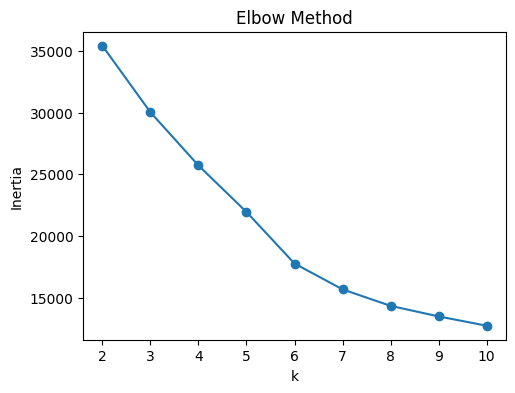

In [ ]:
# (plot elbow & silhouette)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K, inertia, '-o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow Method')

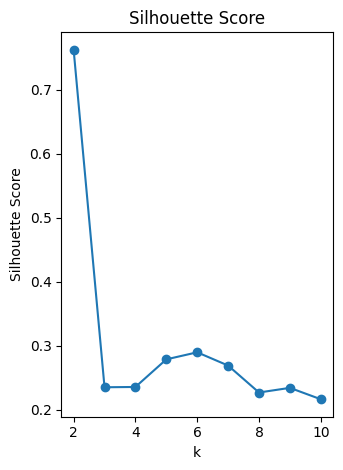

In [ ]:
plt.subplot(1,2,2)
plt.plot(K, sil_scores, '-o')
plt.xlabel('k'); plt.ylabel('Silhouette Score'); plt.title('Silhouette Score')
plt.tight_layout()
plt.show()

In [ ]:
# Fit final kmeans and attach labels
kmeans = KMeans(n_clusters=6, random_state=42, n_init=20)
cust['cluster'] = kmeans.fit_predict(X_scaled)

In [ ]:
# Cluster profiling (aggregations per cluster)
cluster_profile = cust.groupby('cluster').agg(
    n_customers = ('CustomerID', 'count'),
    avg_recency = ('recency', 'mean'),
    avg_frequency = ('frequency', 'mean'),
    avg_monetary = ('monetary', 'mean'),
    median_monetary = ('monetary', 'median'),
    avg_basket = ('avg_basket_value', 'mean'),
    avg_qty = ('avg_item_qty', 'mean'),
    avg_return_rate = ('return_rate', 'mean'),
    avg_distinct_products = ('num_distinct_products', 'mean')
).round(2).reset_index()


In [ ]:
print(cluster_profile)

   cluster  n_customers  avg_recency  avg_frequency  avg_monetary  \
0        0           52       227.92           1.62       -251.73   
1        1         2399        39.91           6.79       2453.37   
2        2          306        69.61           6.34       2748.07   
3        3         1593       171.50           1.79        376.23   
4        4            1         1.00        3710.00    1447682.12   
5        5           22        15.18          46.36      44875.76   

   median_monetary  avg_basket  avg_qty  avg_return_rate  \
0           -22.95     -220.15    -8.09             0.83   
1          1180.40      491.31    13.35             0.02   
2          1140.43      652.95    14.05             0.03   
3           255.90      253.58    37.61             0.02   
4       1447682.12     3192.39     2.00             0.01   
5         13515.55     1753.50    94.48             0.06   

   avg_distinct_products  
0                   6.50  
1                  89.77  
2             

In [ ]:
# Top products per cluster (product preference)
# For each cluster, join back to line-level df and compute top StockCodes by monetary or qty
df_merged = df.merge(cust[['CustomerID','cluster']], on='CustomerID', how='left')
top_products = (
    df_merged.groupby(['cluster','StockCode'])['Amount']
    .sum().abs().reset_index().sort_values(['cluster','Amount'], ascending=[True,False])
)

In [ ]:
top_products_by_cluster = top_products.groupby('cluster').head(10)

__Q: Who are our most valuable customers?__

In [ ]:
top_customers = cust.sort_values('monetary', ascending=False).head(20)
top_customers[['CustomerID','monetary','frequency','recency','country']]

,CustomerID,monetary,frequency,recency,country
4372,Missing_CustID,1447682.12,3710,1,United Kingdom
1703,14646.0,279489.02,77,2,Netherlands
4233,18102.0,256438.49,62,1,United Kingdom
3758,17450.0,187482.17,55,8,United Kingdom
1895,14911.0,132572.62,248,1,EIRE
55,12415.0,123725.45,26,24,Australia
1345,14156.0,113384.14,66,10,EIRE
3801,17511.0,88125.38,46,3,United Kingdom
3202,16684.0,65892.08,31,4,United Kingdom
1005,13694.0,62653.10,60,4,United Kingdom


Although Missing_CustID appears as the top customer based on monetary value and frequency, it does not represent a real individual customer. Instead, it is a placeholder created for transactions with missing CustomerIDs. Therefore, it should be excluded from customer segmentation and behavioral analysis to prevent distorted insights. After removing Missing_CustID, Customer 14646 (Netherlands) emerges as the true highest-value customer.

__Q: What are their demographics (country, etc.)?__

In [ ]:
# Top countries by revenue
country_agg = df_merged.groupby('Country')['Amount'].sum().sort_values(ascending=False).head(10)
country_agg

,Amount
Country,
United Kingdom,8187806.364
Netherlands,284661.540
EIRE,263276.820
Germany,221698.210
France,197403.900
Australia,137077.270
Switzerland,56385.350
Spain,54774.580
Belgium,40910.960


In [ ]:
# Country distribution for top customers
top_country_distribution = top_customers['country'].value_counts()
top_country_distribution

,count
country,
United Kingdom,16
EIRE,2
Netherlands,1
Australia,1


Q: What are their purchase patterns (frequency, quantity, revenue)?

In [ ]:
cust[['CustomerID','recency','frequency','monetary','avg_item_qty']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
recency,4373.0,92.026298,100.763317,1.00,17.000000,50.000000,143.00,374.00
frequency,4373.0,5.922708,56.798813,1.00,1.000000,3.000000,5.00,3710.00
monetary,4373.0,2229.075677,23356.826780,-4287.63,293.450000,648.410000,1612.13,1447682.12
avg_item_qty,4373.0,22.384624,213.233299,-144.00,5.461538,9.494048,14.00,12540.00


Q: What are the distinct customer segments? Are there groups with similar purchase behavior?

In [ ]:
cust.groupby('cluster').agg(
    n_customers=('CustomerID','count'),
    avg_monetary=('monetary','mean'),
    avg_frequency=('frequency','mean'),
    avg_recency=('recency','mean')
).sort_values('avg_monetary', ascending=False)

,n_customers,avg_monetary,avg_frequency,avg_recency
cluster,,,,
4,1,1.447682e+06,3710.000000,1.000000
5,22,4.487576e+04,46.363636,15.181818
2,306,2.748066e+03,6.343137,69.611111
1,2399,2.453372e+03,6.789496,39.907461
3,1593,3.762339e+02,1.793471,171.503453
0,52,-2.517271e+02,1.615385,227.923077


Q: Do certain segments have different product preferences?

In [ ]:
# Example: top 5 stock codes by revenue for each cluster
for c in cust['cluster'].unique():
    top = (df_merged[df_merged['cluster']==c]
           .groupby('StockCode')['Amount'].sum()
           .abs().sort_values(ascending=False).head(10))
    print("Cluster", c)
    print(top)
    print()


Cluster 0
StockCode
M        9449.46
22699     434.30
22942     367.20
22689     337.50
22655     250.00
22580     237.60
21537     180.00
21232     152.64
22474     136.00
22591     127.50
Name: Amount, dtype: float64

Cluster 1
StockCode
22423     90586.65
85099B    59291.89
85123A    57833.11
47566     52269.63
84879     47239.42
22086     36647.68
21137     34122.41
22197     31297.73
82484     30966.01
23298     30001.24
Name: Amount, dtype: float64

Cluster 2
StockCode
POST     66748.71
22423    18062.40
23084    13783.00
22326     9463.10
21731     6311.85
22629     5977.50
22720     5973.45
22492     5647.80
22554     4980.45
22556     4796.25
Name: Amount, dtype: float64

Cluster 3
StockCode
22502     41018.40
M         37094.71
85123A    12847.65
79321      9279.65
22423      8944.30
47566      8847.05
21108      6934.11
85099B     6323.97
47556B     6045.00
84078A     5966.55
Name: Amount, dtype: float64

Cluster 5
StockCode
85123A    22199.14
22423     15289.80
85099B    14

Q: Are there opportunities to increase revenue per customer? Upsell/cross-sell?

In [ ]:
# fast approximation: for each invoice, get stockcodes as list, then explode pairs
basket = df.groupby('InvoiceNo')['StockCode'].apply(lambda x: list(x.unique()))
from itertools import combinations
from collections import Counter

pairs = Counter()
for items in basket:
    for a,b in combinations(sorted(items), 2):
        pairs[(a,b)] += 1

# Most common pairs
pairs.most_common(20)


[(('22386', '85099B'), 833),
 (('22697', '22699'), 784),
 (('21931', '85099B'), 733),
 (('22411', '85099B'), 683),
 (('20725', '22383'), 663),
 (('20725', '20727'), 648),
 (('22726', '22727'), 646),
 (('22697', '22698'), 644),
 (('22698', '22699'), 614),
 (('20725', '22384'), 613),
 (('85099B', '85099C'), 593),
 (('20725', '85099B'), 588),
 (('20727', '22383'), 587),
 (('23203', '85099B'), 582),
 (('20725', '22382'), 563),
 (('20725', '20728'), 562),
 (('22086', '22910'), 555),
 (('23199', '85099B'), 555),
 (('23300', '23301'), 549),
 (('20727', '22384'), 547)]

Q: How do we retain high-value customers? Characteristics of loyal customers? Reduce churn?

In [ ]:
# Define churn: no purchase in last N days (e.g., 180)
N = 180
cust['churned'] = cust['last_purchase_date'] < (analysis_date - pd.Timedelta(days=N))

# Loyal if frequency >= threshold and recency < threshold
cust['is_loyal'] = (cust['frequency'] >= 5) & (cust['recency'] <= 90)

# Compare loyalty features
cust.groupby('is_loyal').agg(
    avg_monetary=('monetary','mean'),
    avg_recency=('recency','mean'),
    avg_frequency=('frequency','mean'),
    avg_return_rate=('return_rate','mean')
)

,avg_monetary,avg_recency,avg_frequency,avg_return_rate
is_loyal,,,,
False,641.392890,120.149263,2.175208,0.031456
True,6191.302423,21.842526,15.274980,0.033497


For each cluster you should create a short profile. Example template to generate automatically:

In [ ]:
profiles = []
for c, grp in cust.groupby('cluster'):
    profile = {
        'cluster': c,
        'n_customers': int(grp.shape[0]),
        'avg_monetary': float(grp['monetary'].mean()),
        'avg_frequency': float(grp['frequency'].mean()),
        'avg_recency': float(grp['recency'].mean()),
        'avg_return_rate': float(grp['return_rate'].mean()),
        'top_countries': grp['country'].value_counts().head(3).to_dict()
    }
    profiles.append(profile)
profiles


[{'cluster': 0,
  'n_customers': 52,
  'avg_monetary': -251.7271153846154,
  'avg_frequency': 1.6153846153846154,
  'avg_recency': 227.92307692307693,
  'avg_return_rate': 0.8324754901960785,
  'top_countries': {'United Kingdom': 45, 'Spain': 2, 'USA': 2}},
 {'cluster': 1,
  'n_customers': 2399,
  'avg_monetary': 2453.372335556482,
  'avg_frequency': 6.7894956231763235,
  'avg_recency': 39.90746144226761,
  'avg_return_rate': 0.020106747053708737,
  'top_countries': {'United Kingdom': 2337, 'France': 8, 'Spain': 6}},
 {'cluster': 2,
  'n_customers': 306,
  'avg_monetary': 2748.0657843137255,
  'avg_frequency': 6.3431372549019605,
  'avg_recency': 69.61111111111111,
  'avg_return_rate': 0.025436738101050974,
  'top_countries': {'Germany': 84, 'France': 67, 'Belgium': 21}},
 {'cluster': 3,
  'n_customers': 1593,
  'avg_monetary': 376.2338549905838,
  'avg_frequency': 1.7934714375392342,
  'avg_recency': 171.50345260514752,
  'avg_return_rate': 0.024796861266999554,
  'top_countries': {'U

In [ ]:
# CLTV (simple historical) = avg_order_value * frequency * margin_factor
cust['avg_order_value'] = cust['monetary'] / cust['frequency'].replace(0,1)
cust['simple_CLTV'] = cust['avg_order_value'] * cust['frequency']

# Repeat purchase rate
repeat_rate = (cust['frequency'] > 1).mean()

# Churn fraction
churn_rate = cust['churned'].mean()

In [ ]:
repeat_rate

np.float64(0.6997484564372285)

In [ ]:
churn_rate

np.float64(0.1984907386233707)